In [1]:
from skimage import data

import napari

viewer = napari.Viewer()
new_layer = viewer.add_image(data.astronaut(), rgb=True)

In [2]:
import numpy as np
import pandas as pd
import napari
import os
import tifffile
from skimage import io
import cv2

In [3]:
in_dir = r'..\results'

In [4]:
merscope_colors = pd.read_pickle(os.path.join(in_dir, 'merscope_colors.pkl'))

In [5]:
embedding_cluster_colors = pd.read_pickle(r'..\results\dann\common_genes\embedding_leiden_colors.pkl')

In [6]:
import matplotlib.pyplot as plt

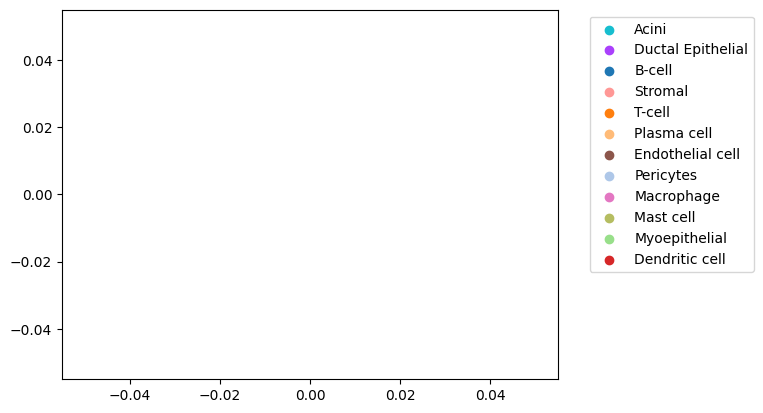

In [7]:
for cell_type in merscope_colors.keys():
    plt.scatter([], [], c=merscope_colors[cell_type], label=cell_type)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

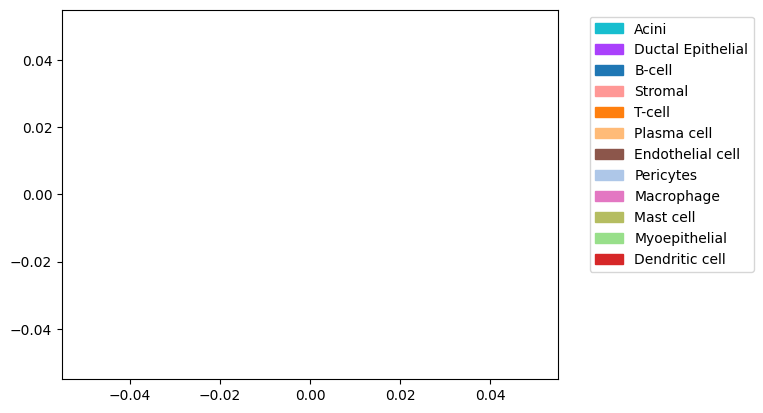

In [8]:
for cell_type in merscope_colors.keys():
    plt.fill([], [], c=merscope_colors[cell_type], label=cell_type)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [7]:
stromal_annotation = pd.read_csv(r'..\results\stromal_adata_obs.csv')
colors = pd.read_pickle(r'..\results\stromal_colors.pkl')

# R1

In [7]:
data = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R1_7289_annotated.csv'))

In [8]:
data['center_y'] = -data['center_y']  # flip y axis for napari

In [10]:
viewer = napari.Viewer()
for cell_type in data['cell_type'].unique():
    cell_data = data[data['cell_type'] == cell_type]
    points = cell_data[['center_y', 'center_x']].to_numpy()
    color = merscope_colors[cell_type]
    viewer.add_points(points, size=10, face_color=color, name=cell_type)
# viewer.add_points(data[['center_y', 'center_x']].to_numpy(), size=3, face_color='white', name='all_cells')

In [11]:
# layer = viewer.layers['all_cells']

In [12]:
# selected = layer.selected_data

In [13]:
# selected

In [14]:
# # drop selected rows from data
# data_dropped = data.drop(index=selected)

In [15]:
# data_dropped.to_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R1_7289_annotated_filtered.csv'), index=False)

## Subtype of stromal cell locations

In [11]:
r1_stromal = stromal_annotation[stromal_annotation['region']=='R1']

In [12]:
r1_stromal['leiden'].value_counts()

leiden
1    2561
0      17
3      12
4       5
2       5
5       1
Name: count, dtype: int64

In [13]:
r1_stromal['cell'] = r1_stromal['cell'].str.split('-').str[0]

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\95546747.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r1_stromal['cell'] = r1_stromal['cell'].str.split('-').str[0]


In [14]:
r1_stromal['cell'] = r1_stromal['cell'].astype('int64')

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\2991802286.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r1_stromal['cell'] = r1_stromal['cell'].astype('int64')


In [15]:
for l in r1_stromal['leiden'].unique():
    sub_stromal = r1_stromal[r1_stromal['leiden'] == l]
    sub_cells = data[data['cell'].isin(sub_stromal['cell'].tolist())]
    viewer.add_points(sub_cells[['center_y', 'center_x']].to_numpy(), size=10,
                      face_color=colors[l], edge_color=colors[l], symbol='star',
                      name=f'stromal cluster{l}')

## add stromal neighborhood locations

In [16]:
sub_graphs = pd.read_pickle(r'..\results\stromal_neighborhoods\sub_graphs_R1_7289.pkl')
sub_graphs = [item for item in sub_graphs if len(item) > 0]

In [17]:
observation = pd.read_csv(r'..\results\dann\common_genes\MERFISH_embedding_observation.csv', index_col=0)

In [18]:
observation_r1 = observation[observation['tissue_id']=='MERFISH_7289']

In [19]:
centers = []
for graph in sub_graphs:
    nodes = np.unique(graph)
    nodes_data = data[data['cell'].isin(nodes)]
    center_y = nodes_data['center_y'].mean()
    center_x = nodes_data['center_x'].mean()
    centers.append((center_y, center_x))

In [20]:
observation_r1.reset_index()

,index,labels,experiment,tissue_id,leiden
0,33708,SSA+,MERFISH,MERFISH_7289,7
1,33709,SSA+,MERFISH,MERFISH_7289,2
2,33710,SSA+,MERFISH,MERFISH_7289,2
3,33711,SSA+,MERFISH,MERFISH_7289,2
4,33712,SSA+,MERFISH,MERFISH_7289,4
...,...,...,...,...,...
2596,36304,SSA+,MERFISH,MERFISH_7289,0
2597,36305,SSA+,MERFISH,MERFISH_7289,7
2598,36306,SSA+,MERFISH,MERFISH_7289,4
2599,36307,SSA+,MERFISH,MERFISH_7289,1


In [21]:
sub_idx = np.where(observation_r1['leiden']==0)

In [22]:
# transparent fill, red border

for l in observation_r1['leiden'].unique():
    sub_idx = np.where(observation_r1['leiden']==l)[0]
    sub_centers = [centers[i] for i in sub_idx]
    viewer.add_points(centers, size=20, face_color='transparent', edge_color=embedding_cluster_colors[l], name=f'TNS{l}')
    viewer.add_points(centers, text={'string':list(np.arange(len(sub_graphs)).astype(str)), 'font_size':12})
# viewer.add_points(centers, size=20, face_color='transparent', edge_color='red', name='stromal neighborhoods')
# viewer.add_points(centers, text={'string':list(np.arange(len(sub_graphs)).astype(str)), 'font_size': 12})

In [28]:
graph = sub_graphs[869]
edges = []
for item in graph:
    node1 = item[0]
    node2 = item[1]
    node1_data = data[data['cell'] == node1][['center_y', 'center_x']].values.tolist()[0]
    node2_data = data[data['cell'] == node2][['center_y', 'center_x']].values.tolist()[0]
    edges.append([node1_data, node2_data])

In [29]:
viewer.add_shapes(edges, shape_type='line', edge_color='yellow', edge_width=2, name='neighborhood edges')

<Shapes layer 'neighborhood edges [2]' at 0x1e6632d6260>

In [30]:
# node1 = graph[0][0]
# node2 = graph[0][1]
data[data['cell'] == node1][['center_y', 'center_x']].values.tolist()[0]

[-7358.947030917732, 1056.083309538292]

In [89]:
data

<module 'skimage.data' from 'c:\\Users\\zfang38\\AppData\\Local\\anaconda3\\envs\\napari-env2\\lib\\site-packages\\skimage\\data\\__init__.py'>

## H&E

In [31]:
image = cv2.imread(r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\msg_10samples\7289_rotated.png')

In [32]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [33]:
viewer = napari.Viewer()
viewer.add_image(image)

<Image layer 'image' at 0x1e600136ef0>

# R2

In [7]:
data = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R2_7295_annotated.csv'))

In [8]:
viewer = napari.Viewer()
for cell_type in data['cell_type'].unique():
    cell_data = data[data['cell_type'] == cell_type]
    points = cell_data[['center_y', 'center_x']].to_numpy()
    color = merscope_colors[cell_type]
    viewer.add_points(points, size=15, face_color=color, name=cell_type)
viewer.add_points(data[['center_y', 'center_x']].to_numpy(), size=5, face_color='white', name='all_cells')

<Points layer 'all_cells' at 0x18c470ed5d0>

In [ ]:
# layer = viewer.layers['all_cells']

In [ ]:
# selected = layer.selected_data

In [ ]:
# selected

Selection((872, 8780, 4654, 4655, 4656, 4657))

In [ ]:
# # drop selected rows from data
# data_dropped = data.drop(index=selected)

In [ ]:
# data_dropped.to_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R2_7295_annotated_filtered.csv'), index=False)

## stromal cell subtype

In [47]:
r2_stromal = stromal_annotation[stromal_annotation['region']=='R2']

In [48]:
r2_stromal['leiden'].value_counts()

leiden
0    3047
1       5
3       4
4       2
2       1
Name: count, dtype: int64

In [49]:
r2_stromal['cell'] = r2_stromal['cell'].str.split('-').str[0]

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\4134518034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r2_stromal['cell'] = r2_stromal['cell'].str.split('-').str[0]


In [50]:
r2_stromal['cell'] = r2_stromal['cell'].astype('int64')

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\521895796.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r2_stromal['cell'] = r2_stromal['cell'].astype('int64')


In [51]:
for l in r2_stromal['leiden'].unique():
    sub_stromal = r2_stromal[r2_stromal['leiden'] == l]
    sub_cells = data[data['cell'].isin(sub_stromal['cell'].tolist())]
    viewer.add_points(sub_cells[['center_y', 'center_x']].to_numpy(), size=10, face_color=colors[l], edge_color=colors[l], symbol='star', name='stromal '+str(l))

## add stromal neighborhood locations

In [52]:
sub_graphs = pd.read_pickle(r'..\results\stromal_neighborhoods\sub_graphs_R2_7295.pkl')
sub_graphs = [item for item in sub_graphs if len(item) > 0]

In [53]:
centers = []
for graph in sub_graphs:
    nodes = np.unique(graph)
    nodes_data = data[data['cell'].isin(nodes)]
    center_y = nodes_data['center_y'].mean()
    center_x = nodes_data['center_x'].mean()
    centers.append((center_y, center_x))

In [54]:
# transparent fill, red border
viewer.add_points(centers, size=20, face_color='transparent', edge_color='red', name='stromal neighborhoods')
viewer.add_points(centers, text={'string':list(np.arange(len(sub_graphs)).astype(str)), 'font_size': 12})

<Points layer 'Points' at 0x1e65f6c9030>

In [55]:
graph = sub_graphs[65]
edges = []
for item in graph:
    node1 = item[0]
    node2 = item[1]
    node1_data = data[data['cell'] == node1][['center_y', 'center_x']].values.tolist()[0]
    node2_data = data[data['cell'] == node2][['center_y', 'center_x']].values.tolist()[0]
    edges.append([node1_data, node2_data])

In [62]:
viewer.add_shapes(edges, shape_type='line', edge_color='yellow', edge_width=2, name='neighborhood edges')

<Shapes layer 'neighborhood edges' at 0x1e6786df850>

## H&E

In [63]:
image = cv2.imread(r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\msg_10samples\7295_rotated.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [64]:
viewer = napari.Viewer()
viewer.add_image(image)

<Image layer 'image' at 0x1e675f8fd90>

# R3

In [9]:
data = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R3_7320_annotated.csv'))

In [10]:
viewer = napari.Viewer()
for cell_type in data['cell_type'].unique():
    cell_data = data[data['cell_type'] == cell_type]
    points = cell_data[['center_y', 'center_x']].to_numpy()
    color = merscope_colors[cell_type]
    viewer.add_points(points, size=15, face_color=color, name=cell_type)
viewer.add_points(data[['center_y', 'center_x']].to_numpy(), size=5, face_color='white', name='all_cells')

<Points layer 'all_cells' at 0x18c8584e380>

In [ ]:
# layer = viewer.layers['all_cells']

In [ ]:
# selected = layer.selected_data

In [ ]:
# selected

Selection((14705, 14706, 14707, 14708, 3623, 14949, 14950, 14696, 14697, 14698, 14955, 14956, 14957, 14699, 14700, 14960, 14701, 14962, 114, 14964, 14965, 14966, 14967, 14968, 14969, 14970, 14971, 14972, 14973, 14709, 14710, 14711, 14712, 14713, 14714, 14715, 14716, 14717, 14718, 14719, 14720, 14721, 14722, 14723, 14724, 14725, 14726, 14727, 14728, 14729, 14730, 14731, 14732, 14733, 14734, 14735, 14736, 14737, 14738, 14739, 14740, 14741, 14742, 14743, 14744, 14745, 14746, 14747, 14748, 14749, 14750, 14751, 14752, 14753, 14754, 14755, 14756, 14757, 14759, 14760, 14761, 14762, 14763, 14764, 14765, 14766, 14767, 14768, 14769, 14770, 14771, 14772, 14773, 14774, 14775, 14776, 3543, 14702, 14703, 14704))

In [ ]:
# # drop selected rows from data
# data_dropped = data.drop(index=selected)

In [ ]:
# data_dropped.to_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R3_7320_annotated_filtered.csv'), index=False)

## Subtype of stromal cell locations

In [85]:
r3_stromal = stromal_annotation[stromal_annotation['region']=='R3']

In [86]:
r3_stromal['leiden'].value_counts()

leiden
2    2235
5     426
1      18
3       5
0       4
4       1
Name: count, dtype: int64

In [87]:
r3_stromal['cell'] = r3_stromal['cell'].str.split('-').str[0].tolist()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\2464396764.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r3_stromal['cell'] = r3_stromal['cell'].str.split('-').str[0].tolist()


In [88]:
r3_stromal['cell'] = r3_stromal['cell'].astype('int64')

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\3502648045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r3_stromal['cell'] = r3_stromal['cell'].astype('int64')


In [89]:
for l in r3_stromal['leiden'].unique():
    sub_stromal = r3_stromal[r3_stromal['leiden'] == l]
    sub_cells = data[data['cell'].isin(sub_stromal['cell'].tolist())]
    viewer.add_points(sub_cells[['center_y', 'center_x']].to_numpy(), size=10, face_color=colors[l], edge_color=colors[l], symbol='star', name='Stromal '+str(l))

## location of neighborhoods

In [90]:
sub_graphs = pd.read_pickle(r'..\results\stromal_neighborhoods\sub_graphs_R3_7320.pkl')
sub_graphs = [item for item in sub_graphs if len(item) > 0]

In [91]:
centers = []
for graph in sub_graphs:
    nodes = np.unique(graph)
    nodes_data = data[data['cell'].isin(nodes)]
    center_y = nodes_data['center_y'].mean()
    center_x = nodes_data['center_x'].mean()
    centers.append((center_y, center_x))

In [92]:
# transparent fill, red border
viewer.add_points(centers, size=20, face_color='transparent', edge_color='red', name='stromal neighborhoods')
viewer.add_points(centers, text={'string':list(np.arange(len(sub_graphs)).astype(str)), 'font_size': 12})

<Points layer 'Points' at 0x1e6765b8b20>

In [95]:
graph = sub_graphs[1537]
edges = []
for item in graph:
    node1 = item[0]
    node2 = item[1]
    node1_data = data[data['cell'] == node1][['center_y', 'center_x']].values.tolist()[0]
    node2_data = data[data['cell'] == node2][['center_y', 'center_x']].values.tolist()[0]
    edges.append([node1_data, node2_data])

In [98]:
viewer.add_shapes(edges, shape_type='line', edge_color='yellow', edge_width=2, name='neighborhood edges')

<Shapes layer 'neighborhood edges' at 0x1e698a45b10>

## H&E

In [99]:
image = cv2.imread(r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\msg_10samples\7320_rotated.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [100]:
viewer = napari.Viewer()
viewer.add_image(image)

<Image layer 'image' at 0x1e69d12ac80>

# R8

In [11]:
data = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R8_159_annotated.csv'))

In [13]:
viewer = napari.Viewer()
for cell_type in data['cell_type'].unique():
    cell_data = data[data['cell_type'] == cell_type]
    points = cell_data[['center_y', 'center_x']].to_numpy()
    color = merscope_colors[cell_type]
    viewer.add_points(points, size=10, face_color=color, name=cell_type)
viewer.add_points(data[['center_y', 'center_x']].to_numpy(), size=5, face_color='white', name='all_cells')

<Points layer 'all_cells' at 0x17a90b43f70>

In [ ]:
# layer = viewer.layers['all_cells']

In [ ]:
# selected = layer.selected_data

In [ ]:
# selected

Selection((0, 1, 3180, 2093, 2094, 3983, 3984, 3985, 3986, 3987, 564, 3988, 3989, 3990, 3991, 3992, 3993))

In [ ]:
# # drop selected rows from data
# data_dropped = data.drop(index=selected)

In [ ]:
# data_dropped['cell_type'].value_counts()

cell_type
Acini                1421
Stromal               717
Ductal Epithelial     515
Myoepithelial         307
Endothelial cell      282
Plasma cell           246
Pericytes             204
Macrophage            181
T-cell                104
Name: count, dtype: int64

In [ ]:
# data_dropped.to_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R8_159_annotated_filtered.csv'), index=False)

In [41]:
r8_stromal = stromal_annotation[stromal_annotation['region']=='R8']

In [42]:
r8_stromal['leiden'].value_counts()

leiden
3    657
2     29
1     14
0     13
4      1
Name: count, dtype: int64

## Subtype of stromal cell locations

In [103]:
r8_stromal = stromal_annotation[stromal_annotation['region']=='R8']

In [104]:
r8_stromal['cell'] = r8_stromal['cell'].str.split('-').str[0].tolist()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\231258744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r8_stromal['cell'] = r8_stromal['cell'].str.split('-').str[0].tolist()


In [105]:
r8_stromal['cell'] = r8_stromal['cell'].astype('int64')

C:\Users\zfang38\AppData\Local\Temp\ipykernel_145300\4276632041.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r8_stromal['cell'] = r8_stromal['cell'].astype('int64')


In [106]:
for l in r8_stromal['leiden'].unique():
    sub_stromal = r8_stromal[r8_stromal['leiden'] == l]
    sub_cells = data[data['cell'].isin(sub_stromal['cell'].tolist())]
    viewer.add_points(sub_cells[['center_y', 'center_x']].to_numpy(), size=10, face_color=colors[l], edge_color=colors[l], symbol='star', name='Stromal '+str(l))

## location of neighborhoods

In [107]:
sub_graphs = pd.read_pickle(r'..\results\stromal_neighborhoods\sub_graphs_R8_159.pkl')
sub_graphs = [item for item in sub_graphs if len(item) > 0]

In [108]:
observation_r8 = observation[observation['tissue_id']=='MERFISH_159']

In [109]:
centers = []
for graph in sub_graphs:
    nodes = np.unique(graph)
    nodes_data = data[data['cell'].isin(nodes)]
    center_y = nodes_data['center_y'].mean()
    center_x = nodes_data['center_x'].mean()
    centers.append((center_y, center_x))

In [110]:
# transparent fill, red border

for l in observation_r8['leiden'].unique():
    sub_idx = np.where(observation_r8['leiden']==l)[0]
    sub_centers = [centers[i] for i in sub_idx]
    viewer.add_points(centers, size=20, face_color='transparent', edge_color=embedding_cluster_colors[l], name=f'TNS{l}')
    viewer.add_points(centers, text={'string':list(np.arange(len(sub_graphs)).astype(str)), 'font_size':12})
# viewer.add_points(centers, size=20, face_color='transparent', edge_color='red', name='stromal neighborhoods')
# viewer.add_points(centers, text={'string':list(np.arange(len(sub_graphs)).astype(str)), 'font_size': 12})

In [111]:
graph = sub_graphs[170]
edges = []
for item in graph:
    node1 = item[0]
    node2 = item[1]
    node1_data = data[data['cell'] == node1][['center_y', 'center_x']].values.tolist()[0]
    node2_data = data[data['cell'] == node2][['center_y', 'center_x']].values.tolist()[0]
    edges.append([node1_data, node2_data])

In [114]:
viewer.add_shapes(edges, shape_type='line', edge_color='yellow', edge_width=2, name='neighborhood edges')

<Shapes layer 'neighborhood edges' at 0x1e6aa4f3c10>

## H&E

In [115]:
im = io.imread(r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\msg_10samples\159_rotated.png')

c:\Users\zfang38\AppData\Local\anaconda3\envs\napari-env\lib\site-packages\PIL\Image.py:3218: DecompressionBombWarning: Image size (156555264 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [116]:
viewer = napari.Viewer()
viewer.add_image(im)

<Image layer 'im' at 0x1e6a8c0d030>

# R9

In [11]:
data = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R9_163_annotated.csv'))

In [13]:
viewer = napari.Viewer()
for cell_type in data['cell_type'].unique():
    cell_data = data[data['cell_type'] == cell_type]
    points = cell_data[['center_y', 'center_x']].to_numpy()
    color = merscope_colors[cell_type]
    viewer.add_points(points, size=10, face_color=color, name=cell_type)
viewer.add_points(data[['center_y', 'center_x']].to_numpy(), size=5, face_color='white', name='all_cells')

<Points layer 'all_cells' at 0x18c8afb6e60>

In [10]:
layer = viewer.layers['all_cells']

In [49]:
selected = layer.selected_data

In [50]:
selected

Selection((0, 1, 2, 3653, 3654, 3655, 3656, 3657, 599, 601, 3614))

In [51]:
# drop selected rows from data
data_dropped = data.drop(index=selected)

In [52]:
data_dropped.to_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R9_163_annotated_filtered.csv'), index=False)

In [11]:
r9_stromal = stromal_annotation[stromal_annotation['region']=='R9']

In [12]:
r9_stromal['leiden'].value_counts()

leiden
4    426
0    101
1      6
3      6
2      3
Name: count, dtype: int64

## Subtype of stromal cell locations

In [54]:
r9_stromal = stromal_annotation[stromal_annotation['region']=='R9']

In [55]:
r9_stromal['cell'] = r9_stromal['cell'].str.split('-').str[0].tolist()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_48184\259977459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r9_stromal['cell'] = r9_stromal['cell'].str.split('-').str[0].tolist()


In [56]:
r9_stromal['cell'] = r9_stromal['cell'].astype(int)

C:\Users\zfang38\AppData\Local\Temp\ipykernel_48184\3696963022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r9_stromal['cell'] = r9_stromal['cell'].astype(int)


In [16]:
for l in r9_stromal['leiden'].unique():
    sub_stromal = r9_stromal[r9_stromal['leiden'] == l]
    sub_cells = data[data['cell'].isin(sub_stromal['cell'].tolist())]
    viewer.add_points(sub_cells[['center_y', 'center_x']].to_numpy(), size=10, face_color=colors[l], edge_color=colors[l], symbol='star', name='Stromal '+str(l))

c:\Users\zfang38\AppData\Local\anaconda3\envs\napari-env2\lib\site-packages\napari\utils\migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)
c:\Users\zfang38\AppData\Local\anaconda3\envs\napari-env2\lib\site-packages\napari\utils\migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)
c:\Users\zfang38\AppData\Local\anaconda3\envs\napari-env2\lib\site-packages\napari\utils\migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)
c:\Users\zfang38\AppData\Local\anaconda3\envs\napari-env2\lib\site-packag

## location of neighborhoods

In [57]:
sub_graphs = pd.read_pickle(r'..\results\stromal_neighborhoods\sub_graphs_R9_163.pkl')
sub_graphs = [item for item in sub_graphs if len(item) > 0]

In [18]:
centers = []
for graph in sub_graphs:
    nodes = np.unique(graph)
    nodes_data = data[data['cell'].isin(nodes)]
    center_y = nodes_data['center_y'].mean()
    center_x = nodes_data['center_x'].mean()
    centers.append((center_y, center_x))

In [19]:
# transparent fill, red border
viewer.add_points(centers, size=20, face_color='transparent', edge_color='red', name='stromal neighborhoods')
viewer.add_points(centers, text={'string':list(np.arange(len(sub_graphs)).astype(str)), 'font_size': 12})

c:\Users\zfang38\AppData\Local\anaconda3\envs\napari-env2\lib\site-packages\napari\utils\migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)


<Points layer 'Points' at 0x1f8089ded40>

In [20]:
graph = sub_graphs[294]
edges = []
for item in graph:
    node1 = item[0]
    node2 = item[1]
    node1_data = data[data['cell'] == node1][['center_y', 'center_x']].values.tolist()[0]
    node2_data = data[data['cell'] == node2][['center_y', 'center_x']].values.tolist()[0]
    edges.append([node1_data, node2_data])

In [21]:
viewer.add_shapes(edges, shape_type='line', edge_color='yellow', edge_width=2, name='neighborhood edges')

<Shapes layer 'neighborhood edges' at 0x1f80881bd90>

INFO: Selected 268 points in this slice, use Shift-A to select all points on the layer. (268 selected)
INFO: Selected 268 points in this slice, use Shift-A to select all points on the layer. (268 selected)
INFO: Selected 545 points in this slice, use Shift-A to select all points on the layer. (545 selected)
INFO: Selected 286 points in this slice, use Shift-A to select all points on the layer. (286 selected)
INFO: Selected 669 points in this slice, use Shift-A to select all points on the layer. (669 selected)
INFO: Selected 218 points in this slice, use Shift-A to select all points on the layer. (218 selected)
INFO: Selected 414 points in this slice, use Shift-A to select all points on the layer. (414 selected)
INFO: Selected 200 points in this slice, use Shift-A to select all points on the layer. (200 selected)
INFO: Selected 510 points in this slice, use Shift-A to select all points on the layer. (510 selected)
INFO: Selected 548 points in this slice, use Shift-A to select all points

## H&E

In [49]:
image = cv2.imread(r'Y:\coskun-lab\Zhou\12_MSG\MERSCOPE\msg_10samples\163_rotated.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [50]:
viewer = napari.Viewer()
viewer.add_image(image)

<Image layer 'image' at 0x1f82e3056f0>